In [177]:
import numpy as np
import sys
from matplotlib import pyplot as plt
from IPython.display import display, HTML
from raspi_import import raspi_import
from scipy.signal import butter, filtfilt

# BODEPLOT AV FILTRENE

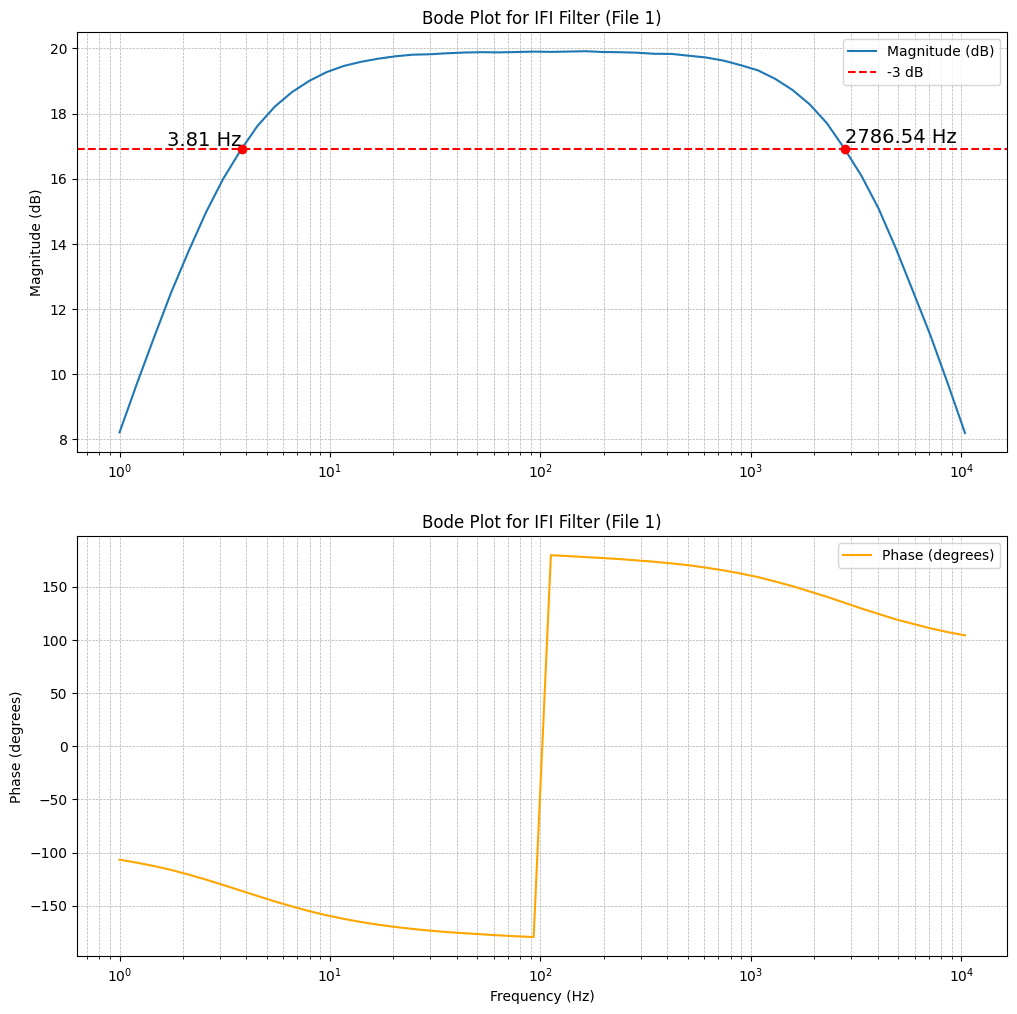

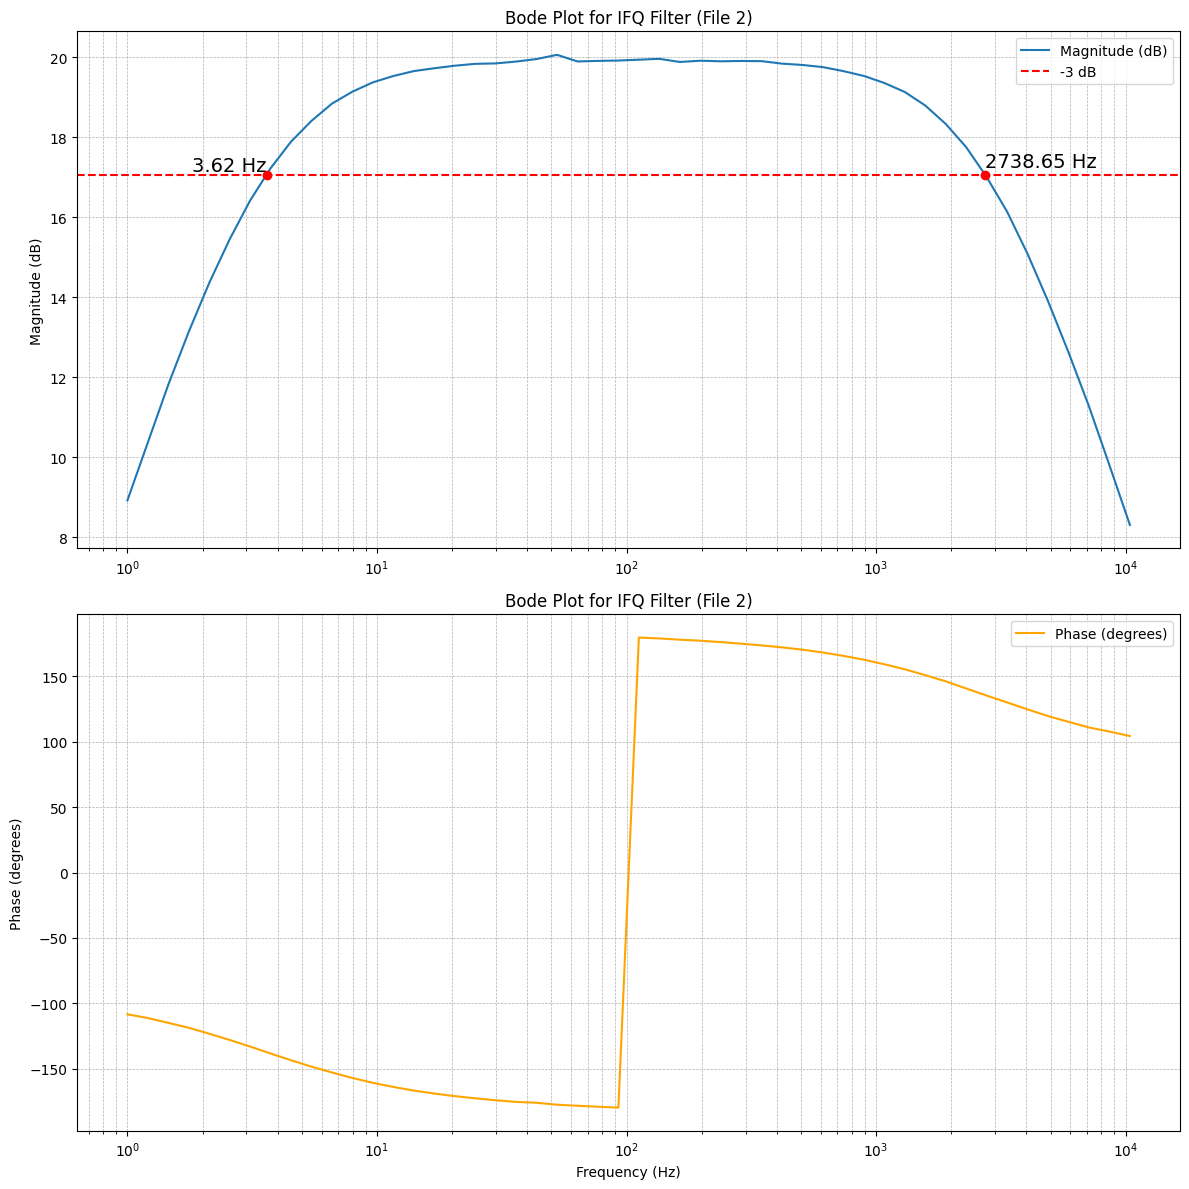

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Les CSV-filene
file_path1 = "Målinger/BP_filter_IF_I_Tidy.csv"  # Sett riktig filsti for første fil
file_path2 = "Målinger/BP_filter_IF_Q_Tidy.csv"  # Sett riktig filsti for andre fil

data1 = pd.read_csv(file_path1)
data2 = pd.read_csv(file_path2)

# Anta at kolonnene i CSV-filene er 'Frequency (Hz)', 'Channel 2 Magnitude (dB)', og 'Channel 2 Phase (deg)'
frequency1 = data1['Frequency (Hz)']
magnitude1 = data1['Channel 2 Magnitude (dB)']
max_magnitude1 = np.max(magnitude1)
knekk1 = max_magnitude1 - 3
phase1 = data1['Channel 2 Phase (deg)']

frequency2 = data2['Frequency (Hz)']
magnitude2 = data2['Channel 2 Magnitude (dB)']
max_magnitude2 = np.max(magnitude2)
knekk2 = max_magnitude2 - 3
phase2 = data2['Channel 2 Phase (deg)']

# Funksjon for å finne krysningspunktet med -3 dB
def find_crossing(frequency, magnitude, threshold):
    idx = np.where(np.diff(np.sign(magnitude - threshold)))[0]  # Finn indeksene der kryssing skjer
    crossings = []
    for i in idx:
        # Lineær interpolasjon for mer nøyaktig krysningspunkt
        x_cross = frequency[i] + (frequency[i+1] - frequency[i]) * (threshold - magnitude[i]) / (magnitude[i+1] - magnitude[i])
        crossings.append(x_cross)
    return crossings

# Finn krysningspunkter for begge datasettene
crossings1 = find_crossing(frequency1, magnitude1, knekk1)
crossings2 = find_crossing(frequency2, magnitude2,knekk2)

# Lag figur for første datasett
plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
plt.semilogx(frequency1, magnitude1, label="Magnitude (dB)")
plt.axhline(knekk1, color='red', linestyle='--', label='-3 dB')
plt.plot(crossings1[0], knekk1, 'ro')  
plt.text(crossings1[0], knekk1+0.1, f"{crossings1[0]:.2f} Hz", color='black', fontsize=14, ha='right')
plt.plot(crossings1[1], knekk1, 'ro')  
plt.text(crossings1[1], knekk1+0.2, f"{crossings1[1]:.2f} Hz", color='black', fontsize=14, ha='left')
plt.title("Bode Plot for IFQ Filter (File 2)")
plt.title("Bode Plot for IFI Filter (File 1)")
plt.ylabel("Magnitude (dB)")
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.subplot(2, 1, 2)
plt.semilogx(frequency1, phase1, label="Phase (degrees)", color="orange")
plt.title("Bode Plot for IFI Filter (File 1)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

# Lag figur for andre datasett
plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
plt.semilogx(frequency2, magnitude2, label="Magnitude (dB)")
plt.axhline(knekk2, color='red', linestyle='--', label='-3 dB')
plt.plot(crossings2[0], knekk2, 'ro')  
plt.text(crossings2[0], knekk2+0.1, f"{crossings2[0]:.2f} Hz", color='black', fontsize=14, ha='right')
plt.plot(crossings2[1], knekk2, 'ro')  
plt.text(crossings2[1], knekk2+0.2, f"{crossings2[1]:.2f} Hz", color='black', fontsize=14, ha='left')
plt.title("Bode Plot for IFQ Filter (File 2)")
plt.ylabel("Magnitude (dB)")
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.subplot(2, 1, 2)
plt.semilogx(frequency2, phase2, label="Phase (degrees)", color="orange")
plt.title("Bode Plot for IFQ Filter (File 2)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.grid(which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# **BEHANDLING AV RÅDATA**

Sample period: 3.2e-05 s
Data shape: (93750, 3)
data type: [[  16.   16. 2048.]
 [1975. 1772. 1021.]
 [1967. 1771.  381.]
 ...
 [ 246. 2526.   39.]
 [ 244. 2530.   37.]
 [ 241. 2534.   36.]]
Sampling frequency: 31250.0
Samples: 93750


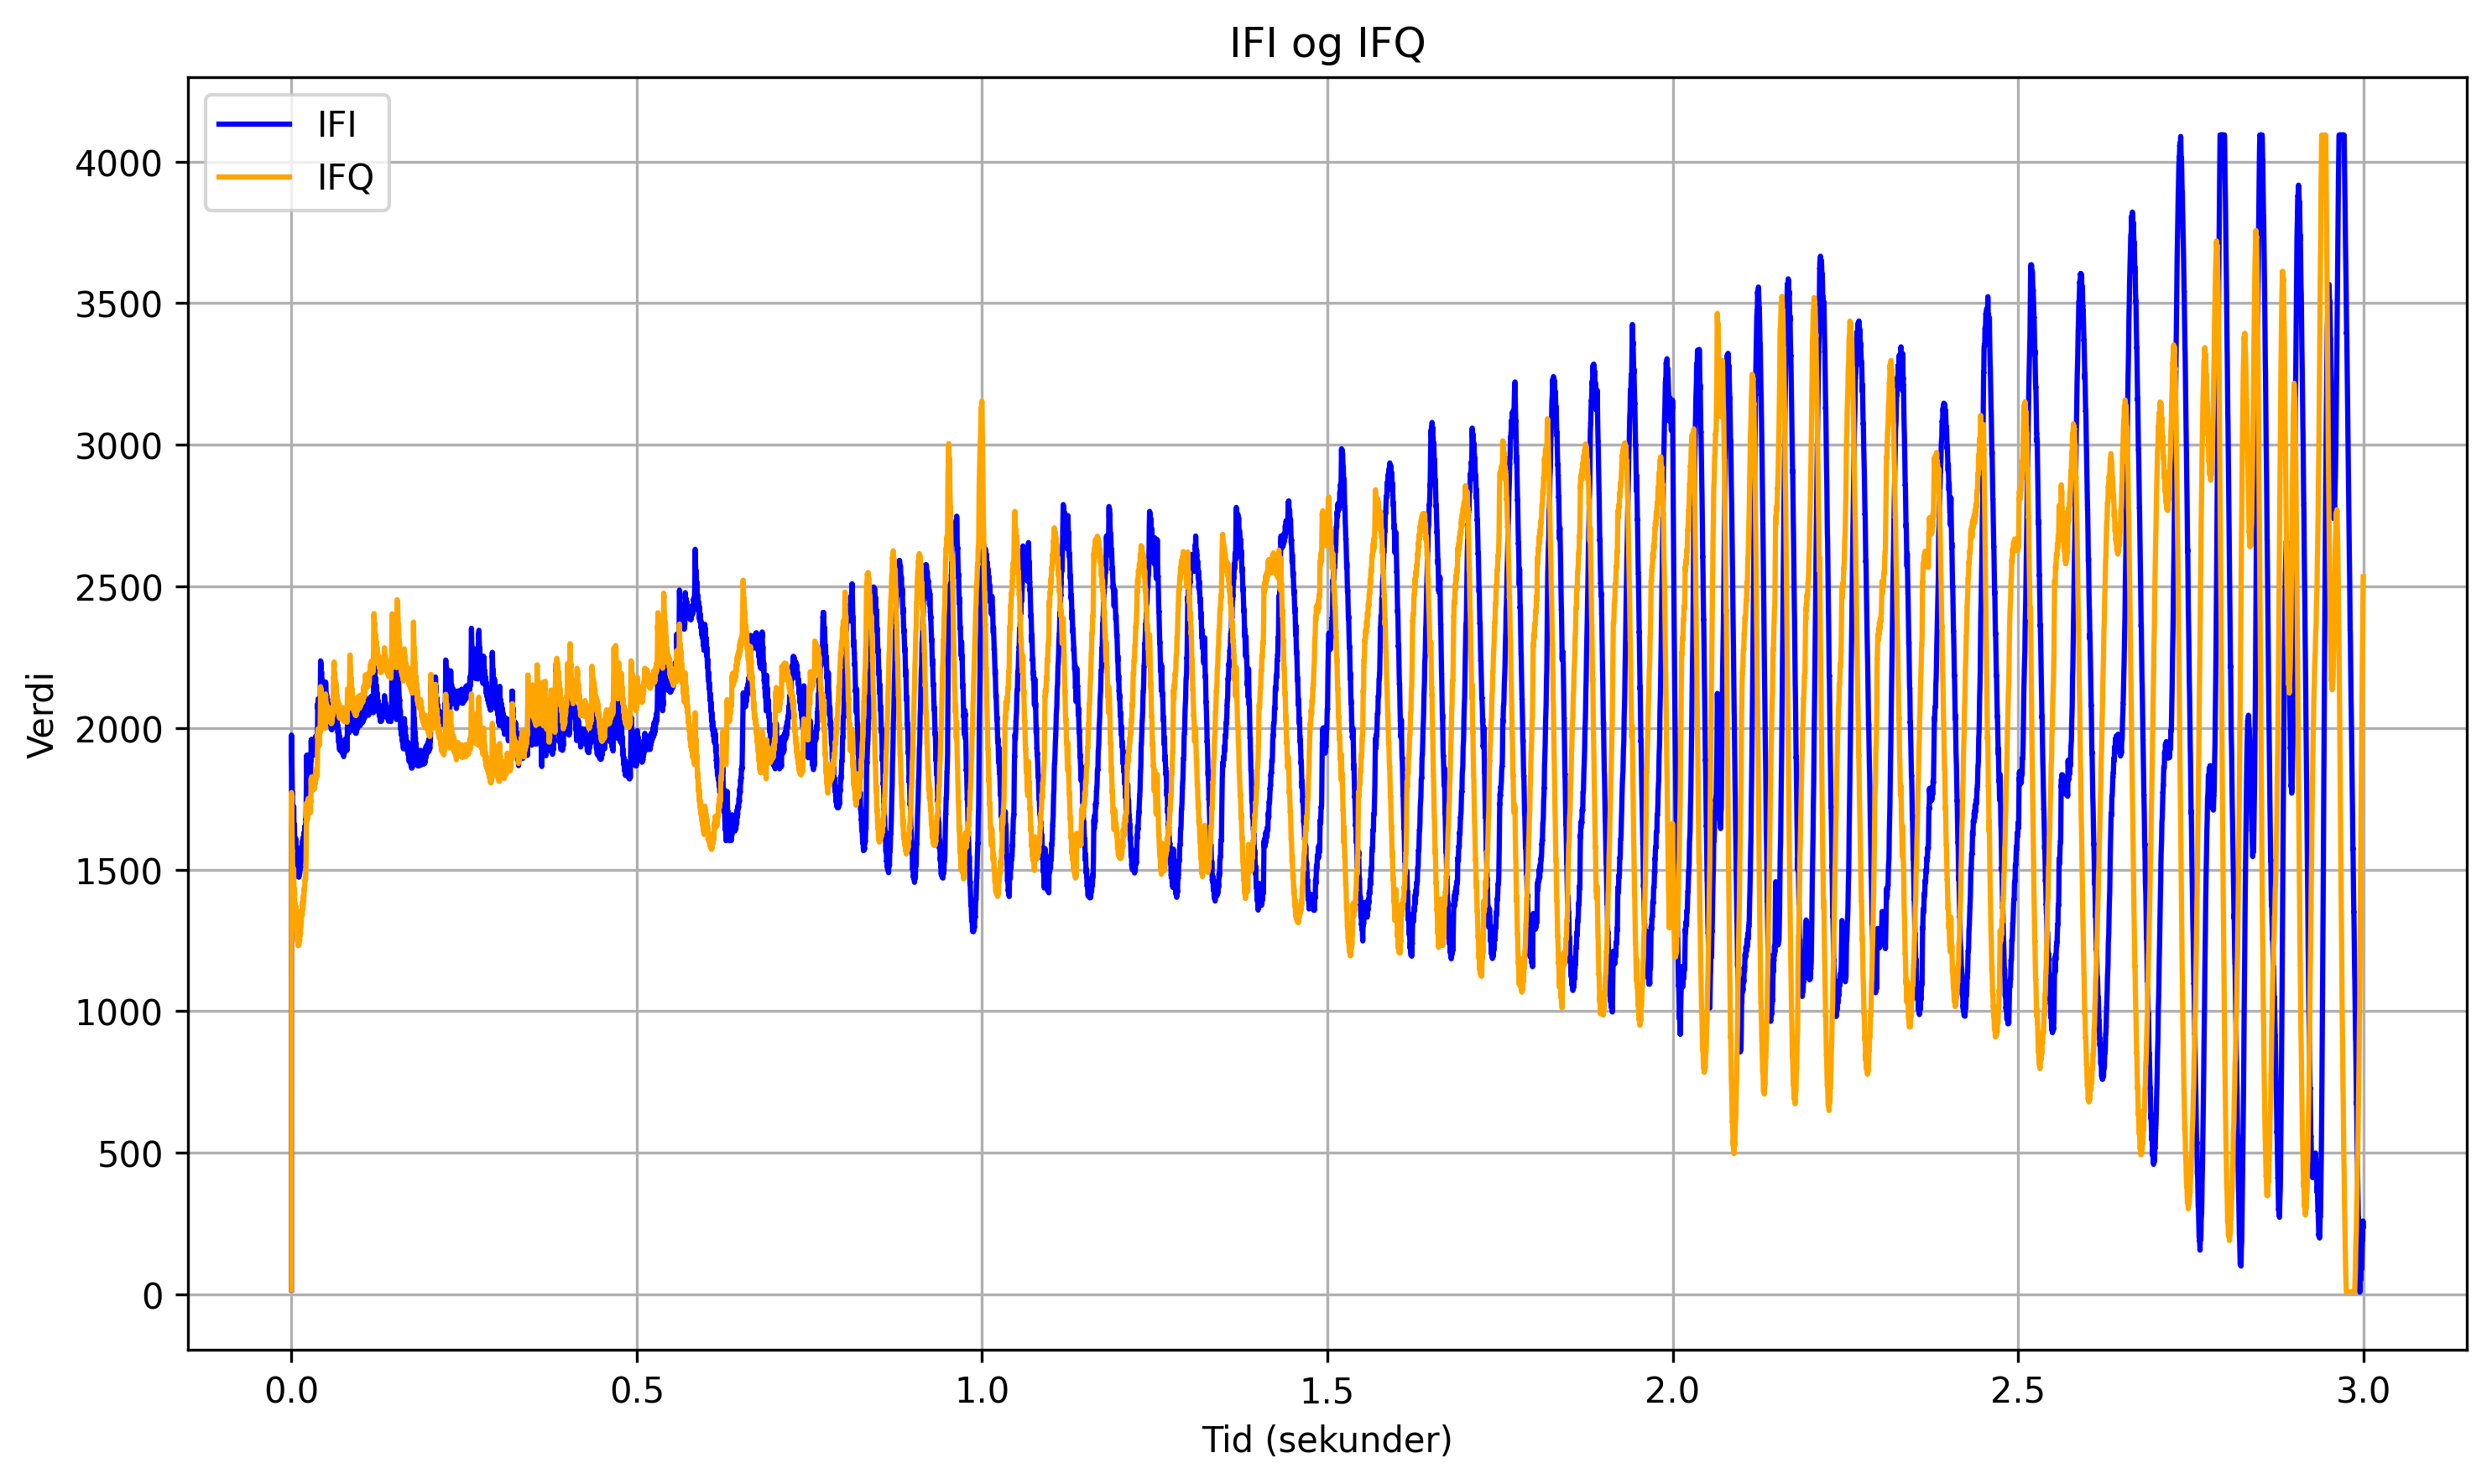

Amplitude IFI: 669.8285307420823
Amplitude IFQ: 643.9236028147101
Scale factor: 1.04022981579513
New amplitude IFQ: 669.8285307420824


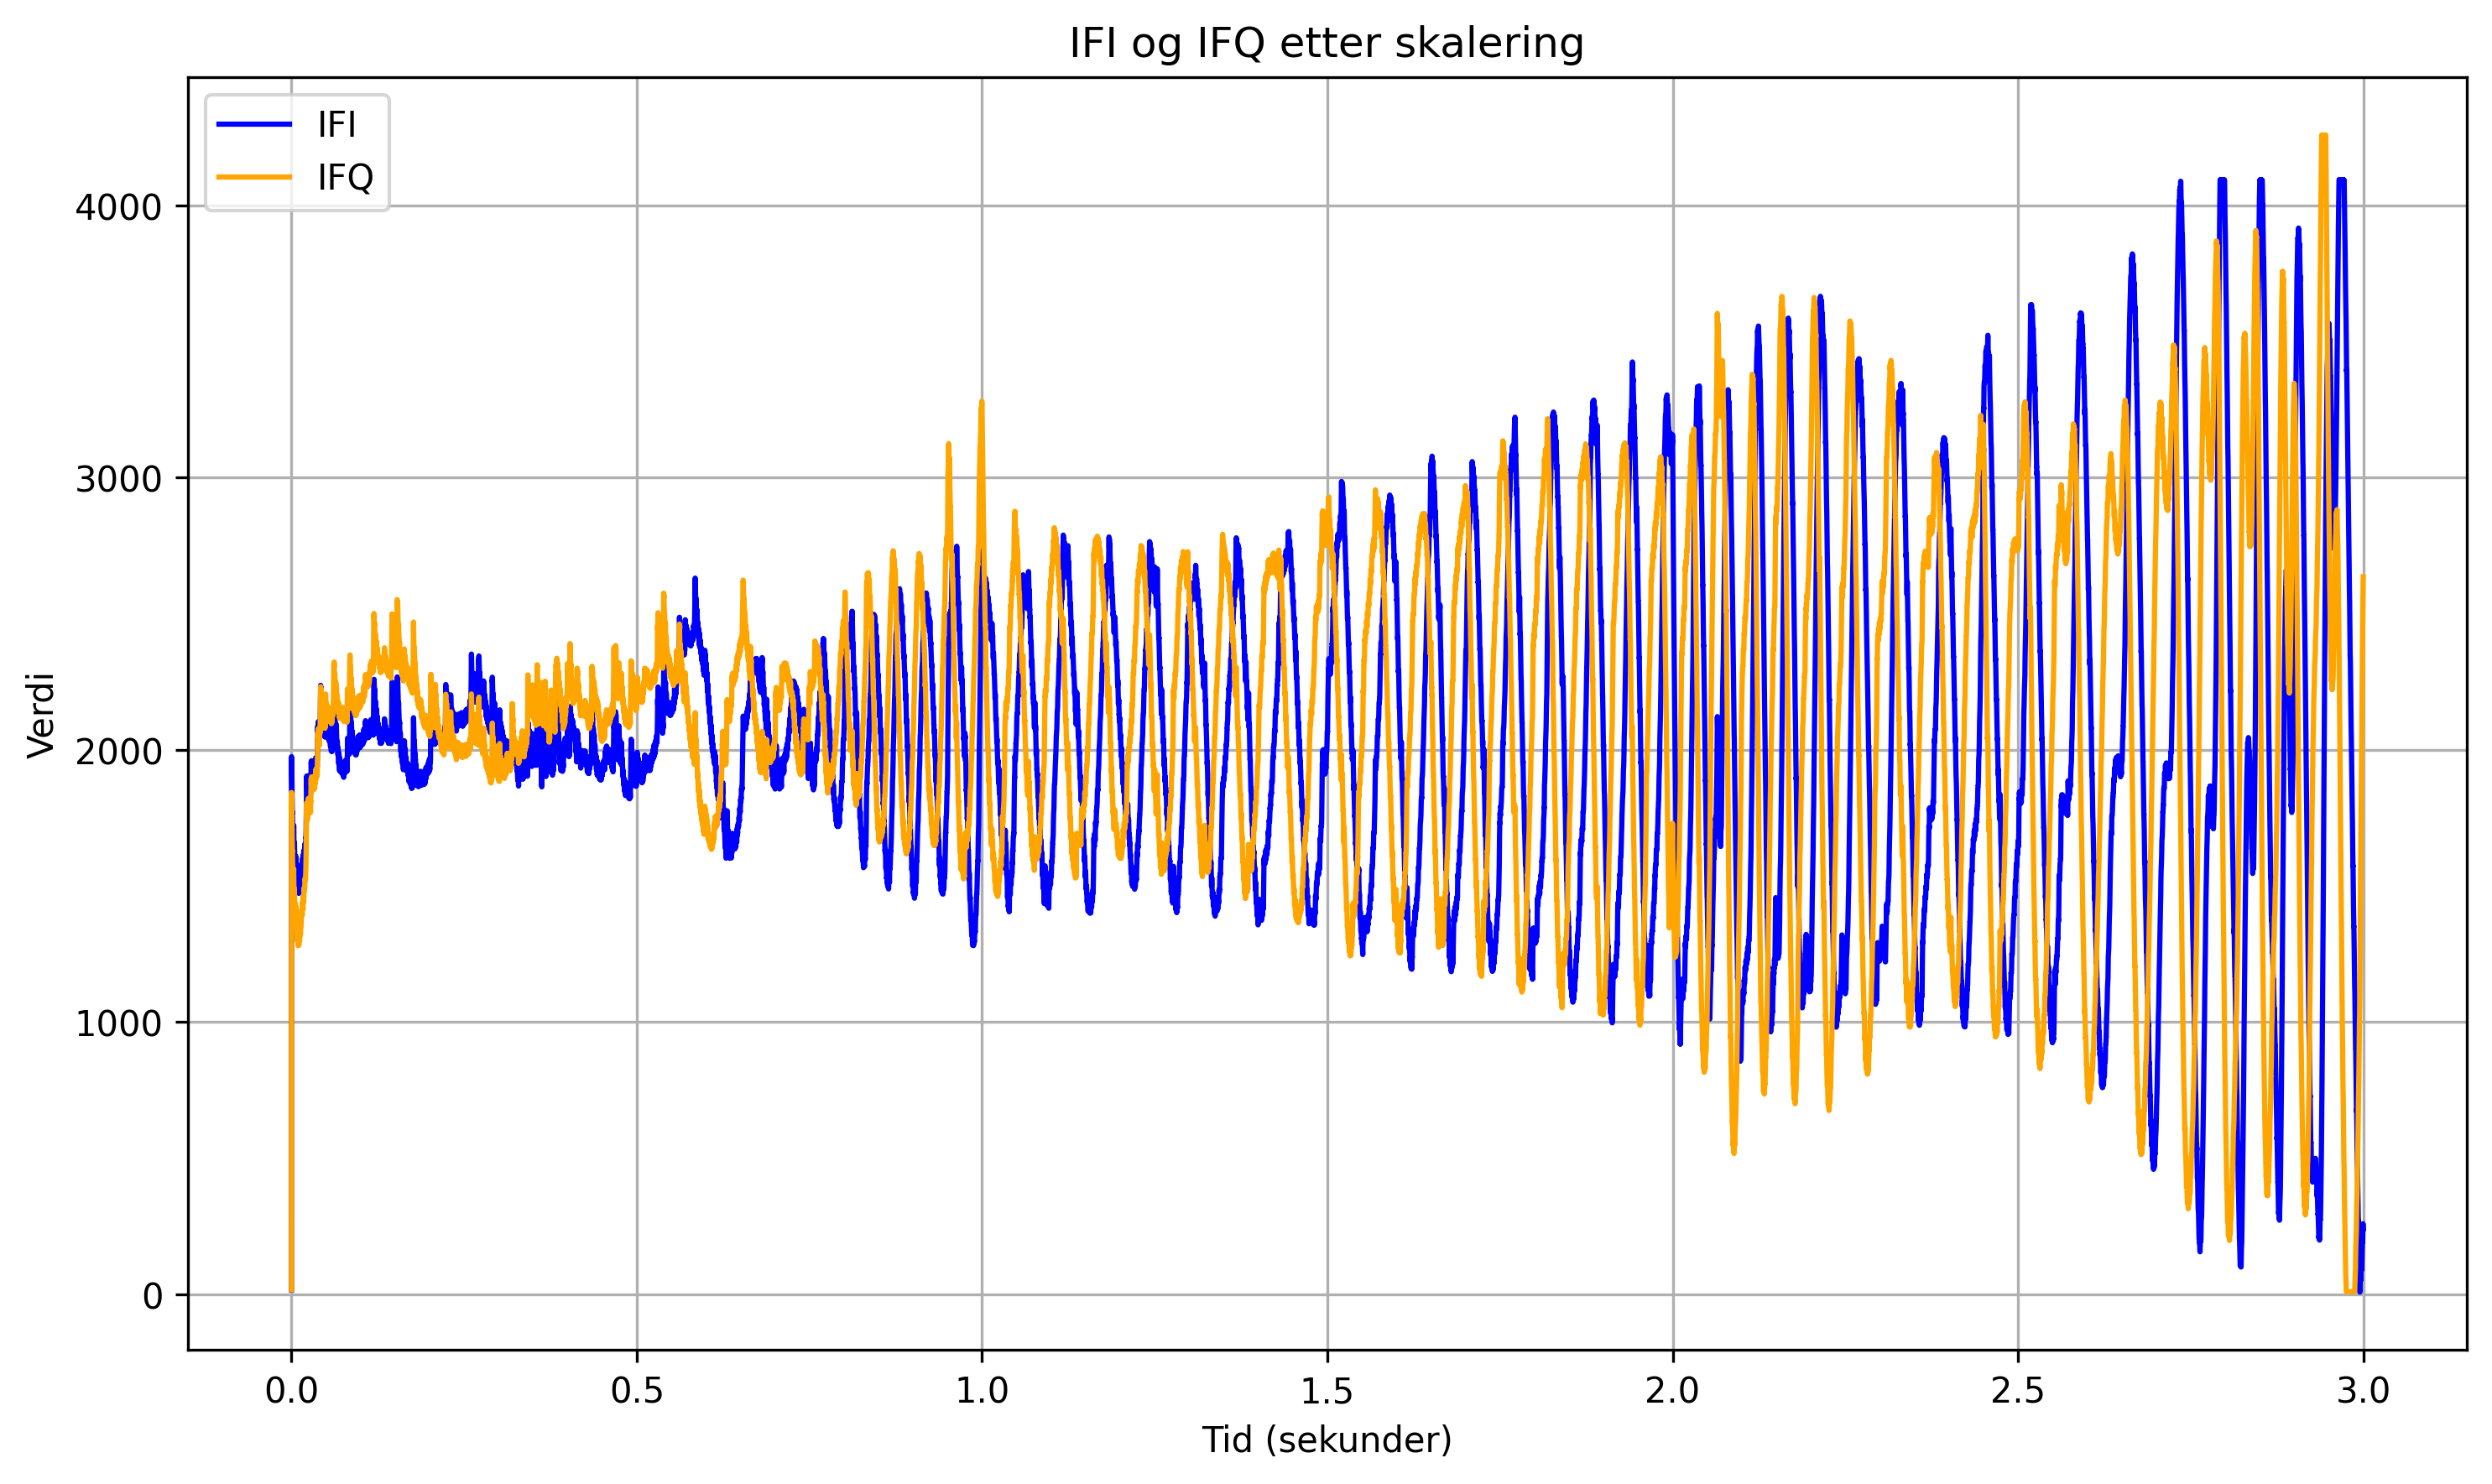

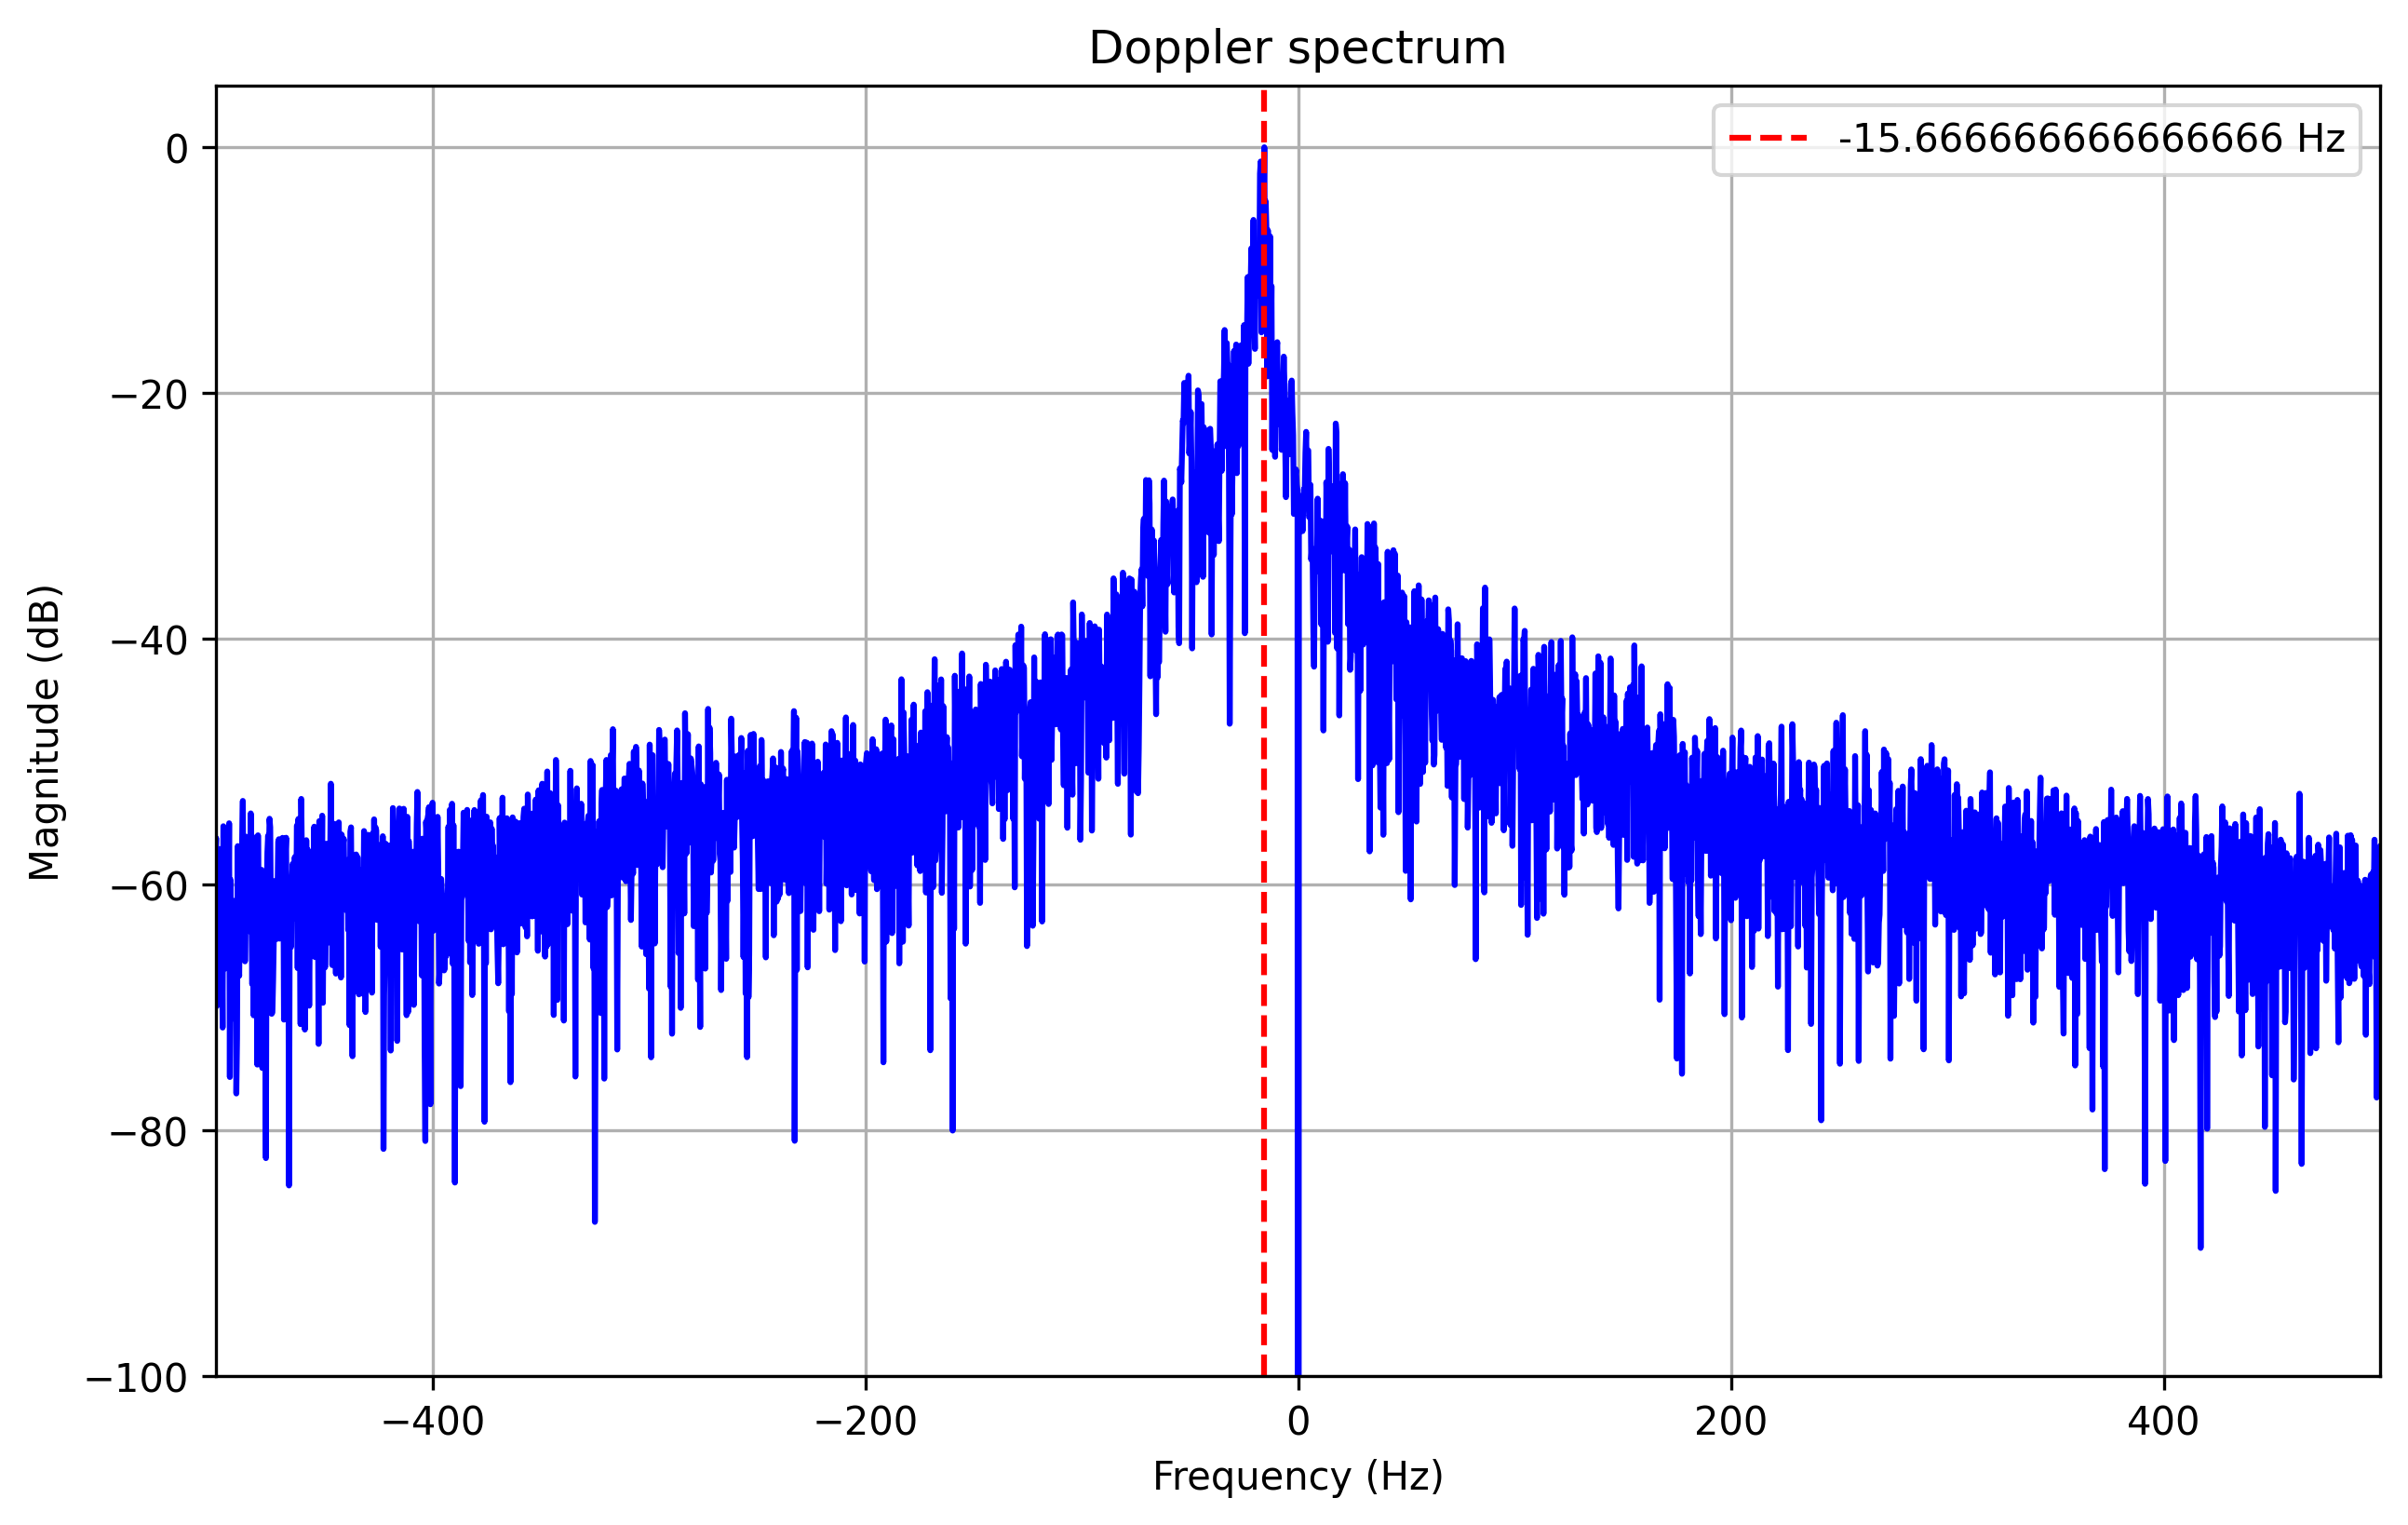

Doppler frequency: -15.666666666666666 Hz
Velocity: -0.09791666666666667 m/s


In [179]:

sample_period, data = raspi_import(
    "Målinger/RadarTest3.bin"
)
display(HTML('<h1>Rådata form og informasjon</h1>'))
print("Sample period:", sample_period, "s")
print("Data shape:", data.shape)
print("data type:", data)


fs = 1 / sample_period
N = len(data)

print("Sampling frequency:", fs)
print("Samples:", N)


# -------------------------
# 1. Velg IFI og IFQ
# -------------------------

IFI = data[:, 0]
IFQ = data[:, 1]

# -------------------------
# 2. Plotte rådata
# -------------------------
display(HTML('<h1>Tidsdomene til rådata </h1>'))
tid = np.arange(len(IFI)) / fs  # Generer tid i sekunder

plt.figure(figsize=(10, 6), dpi=300)
plt.plot(tid, IFI, label="IFI", color="blue")
plt.plot(tid, IFQ, label="IFQ", color="orange")
plt.title("IFI og IFQ")
plt.xlabel("Tid (sekunder)")
plt.ylabel("Verdi")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# -------------------------
# 2.3 Skalering
# -------------------------
display(HTML('<h1>Skalering av råsignal</h1>'))
amp_I = np.std(IFI)
amp_Q = np.std(IFQ)

print("Amplitude IFI:", amp_I)
print("Amplitude IFQ:", amp_Q)

scale = amp_I / amp_Q

IFQ = IFQ * scale
amp_Q = np.std(IFQ)


print("Scale factor:", scale)
print("New amplitude IFQ:", amp_Q)


plt.figure(figsize=(10, 6), dpi=300)
plt.plot(tid, IFI, label="IFI", color="blue")
plt.plot(tid, IFQ, label="IFQ", color="orange")
plt.title("IFI og IFQ etter skalering")
plt.xlabel("Tid (sekunder)")
plt.ylabel("Verdi")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# -------------------------
# 3. Fjern DC offset 
# -------------------------

IFI = IFI - np.mean(IFI)
IFQ = IFQ - np.mean(IFQ)


# -------------------------
# 4. Kompleks signal
# -------------------------

s = IFI + 1j * IFQ


# -------------------------
# 6. FFT
# -------------------------

S = np.fft.fft(s)
S = np.fft.fftshift(S)

freq = np.fft.fftshift(
    np.fft.fftfreq(N, sample_period)
)

# -------------------------
# 8. Finn Doppler peak
# -------------------------

idx = np.argmax(np.abs(S))
f_peak = freq[idx]


# -------------------------
# 7. Spektrum i dB
# -------------------------
display(HTML('<h1>FFT av råsignal </h1>'))
S_db = 20 * np.log10(np.abs(S) + 1e-12)

plt.figure(figsize=(10,6),dpi=300)
plt.plot(freq, S_db-np.max(S_db), color="blue")
plt.axvline(f_peak, color="red", linestyle="--", label=f"{f_peak} Hz")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Doppler spectrum")
plt.legend()
plt.ylim(-100, 5)
plt.xlim(-500,500)
plt.grid()
plt.show()






# -------------------------
# 9. Regn hastighet
# -------------------------

c = 3e8
f_radar = 24e9

lam = c / f_radar

v = f_peak * lam / 2
display(HTML('<h1>Utregnet fart fra råsignal</h1>'))
print("Doppler frequency:", f_peak, "Hz")
print("Velocity:", v, "m/s")




# **BEHANDLING AV FILTRERT SIGNAL**

Vindu type: Hanning
Minimum hastighet (v_min): 1 m/s
Maksimum hastighet (v_max): 2.3 m/s
Minimum frekvens (f_min): 160.00 Hz
Maksimum frekvens (f_max): 368.00 Hz
Filterorden: 3


Amplitude IFI: 9.03926939013075
Amplitude IFQ: 9.536675126155687
Scale factor: 0.9478428561899176
New amplitude IFQ: 9.03926939013075


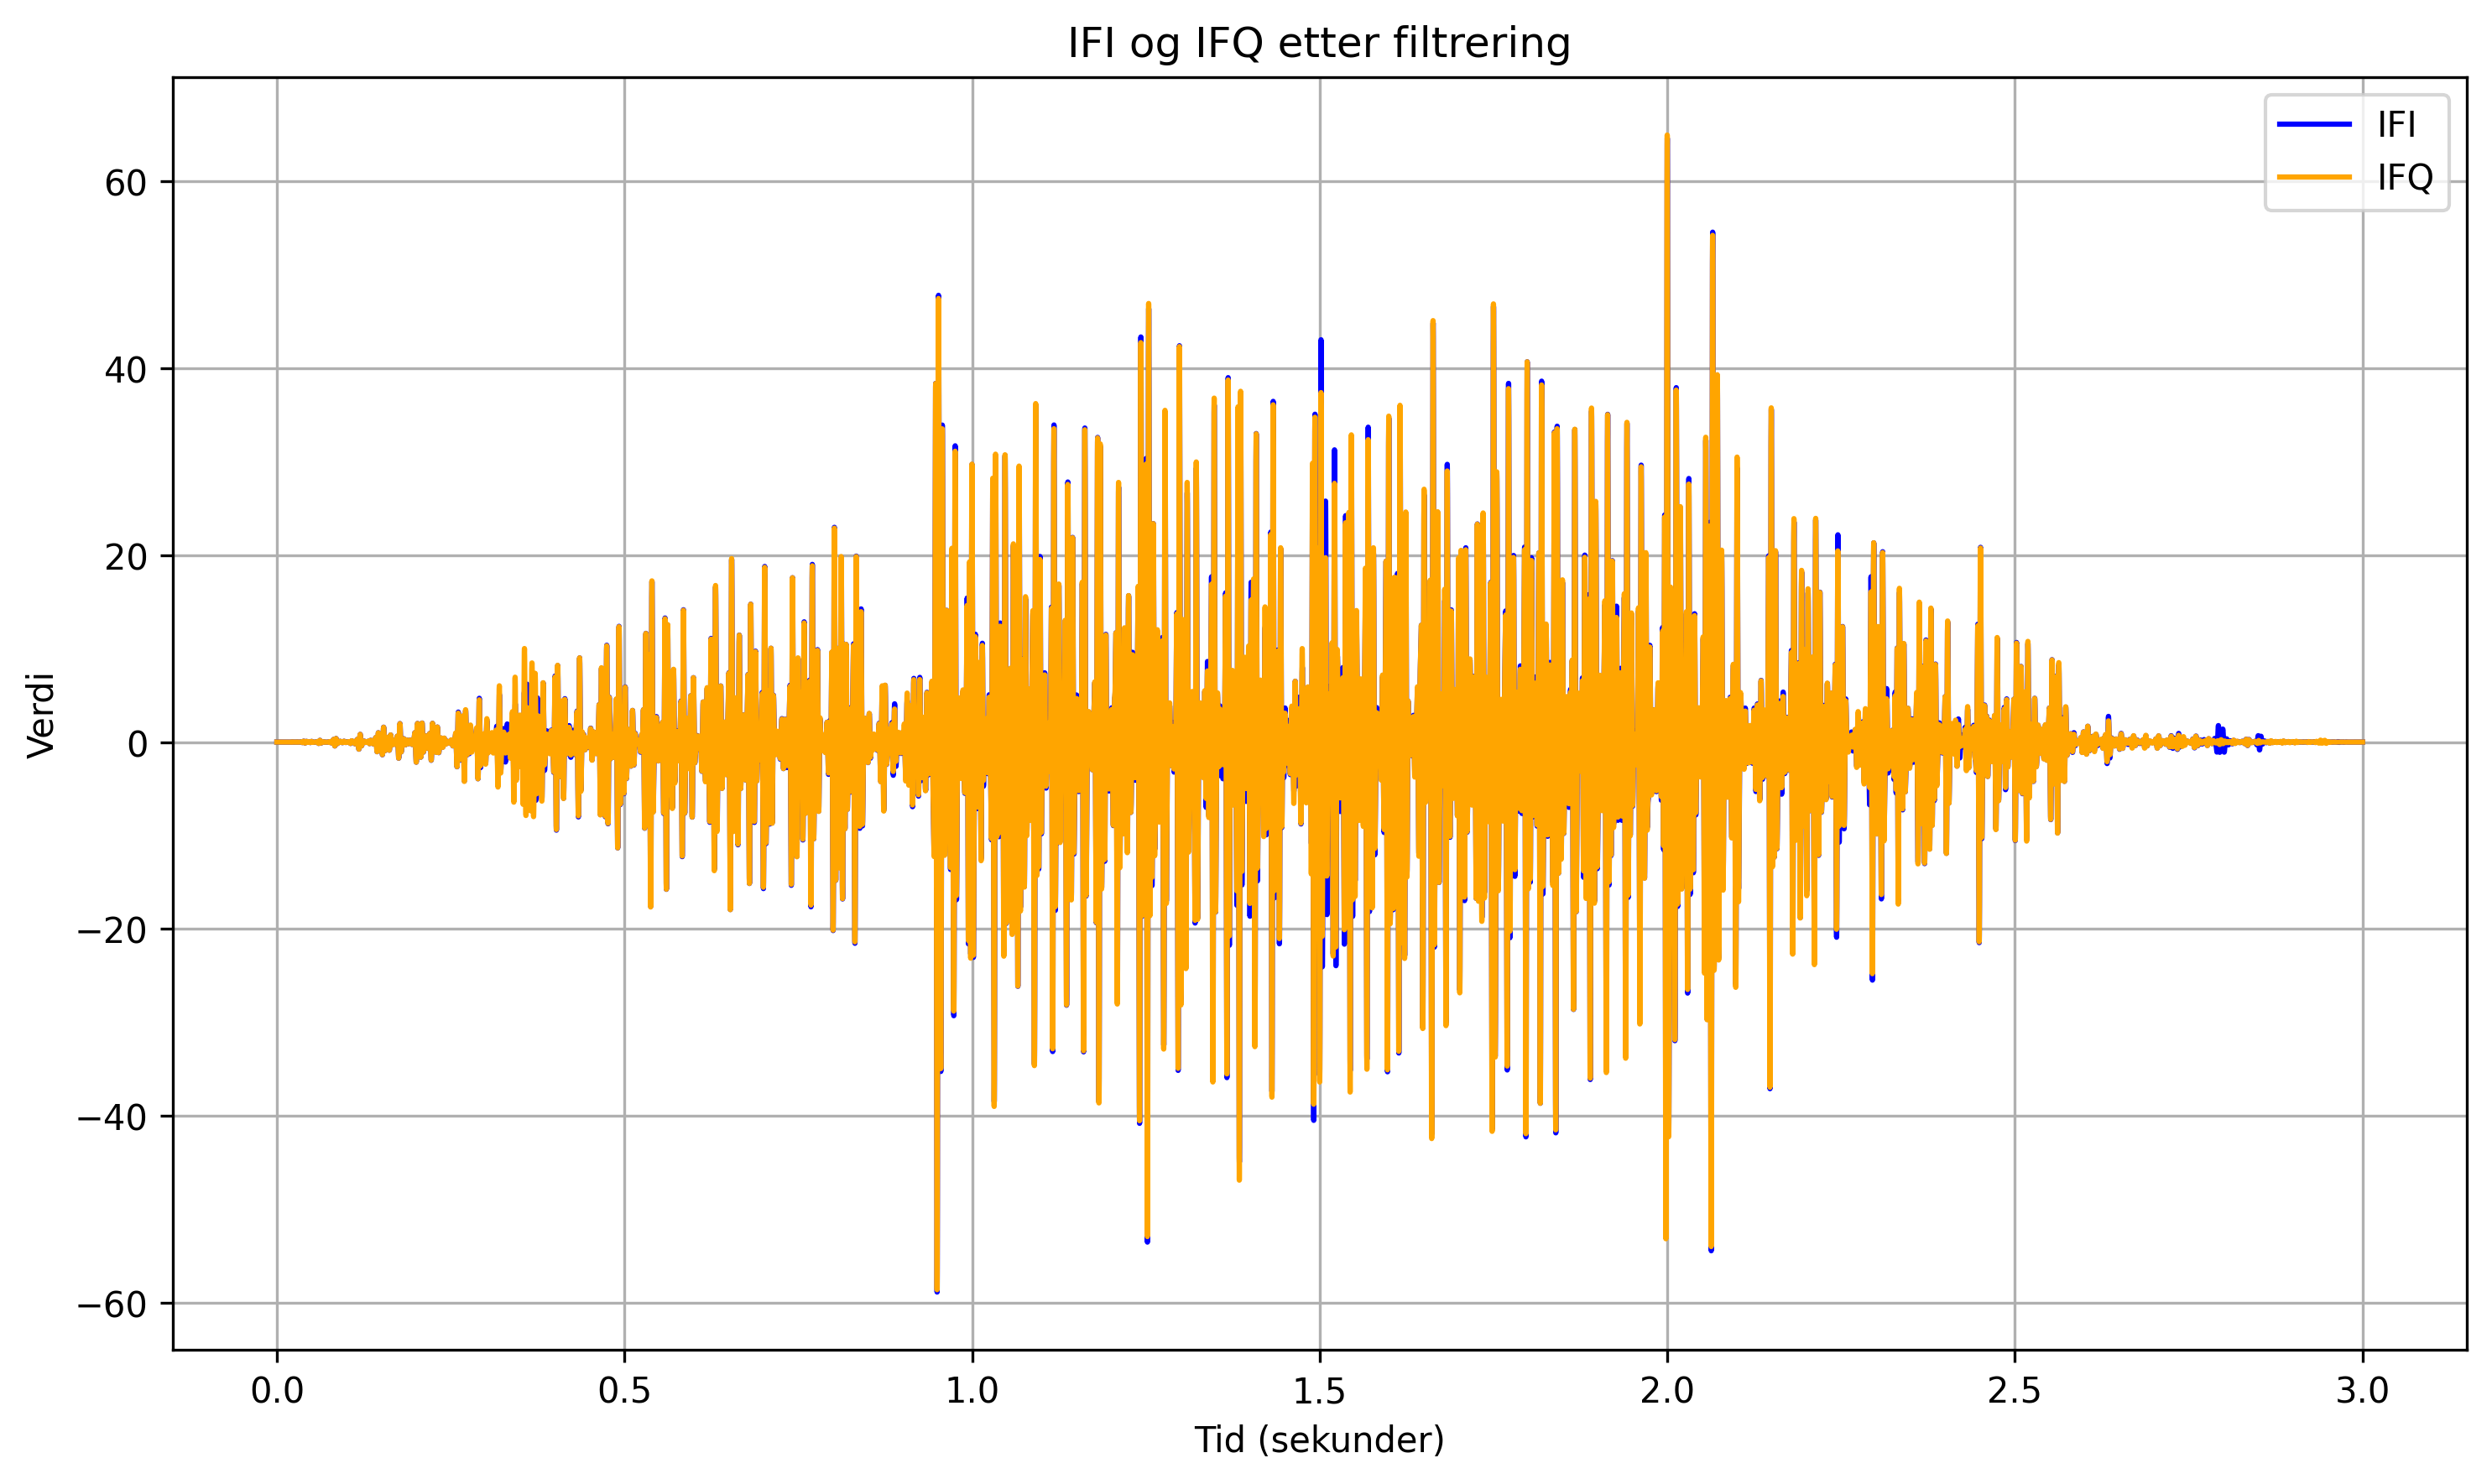

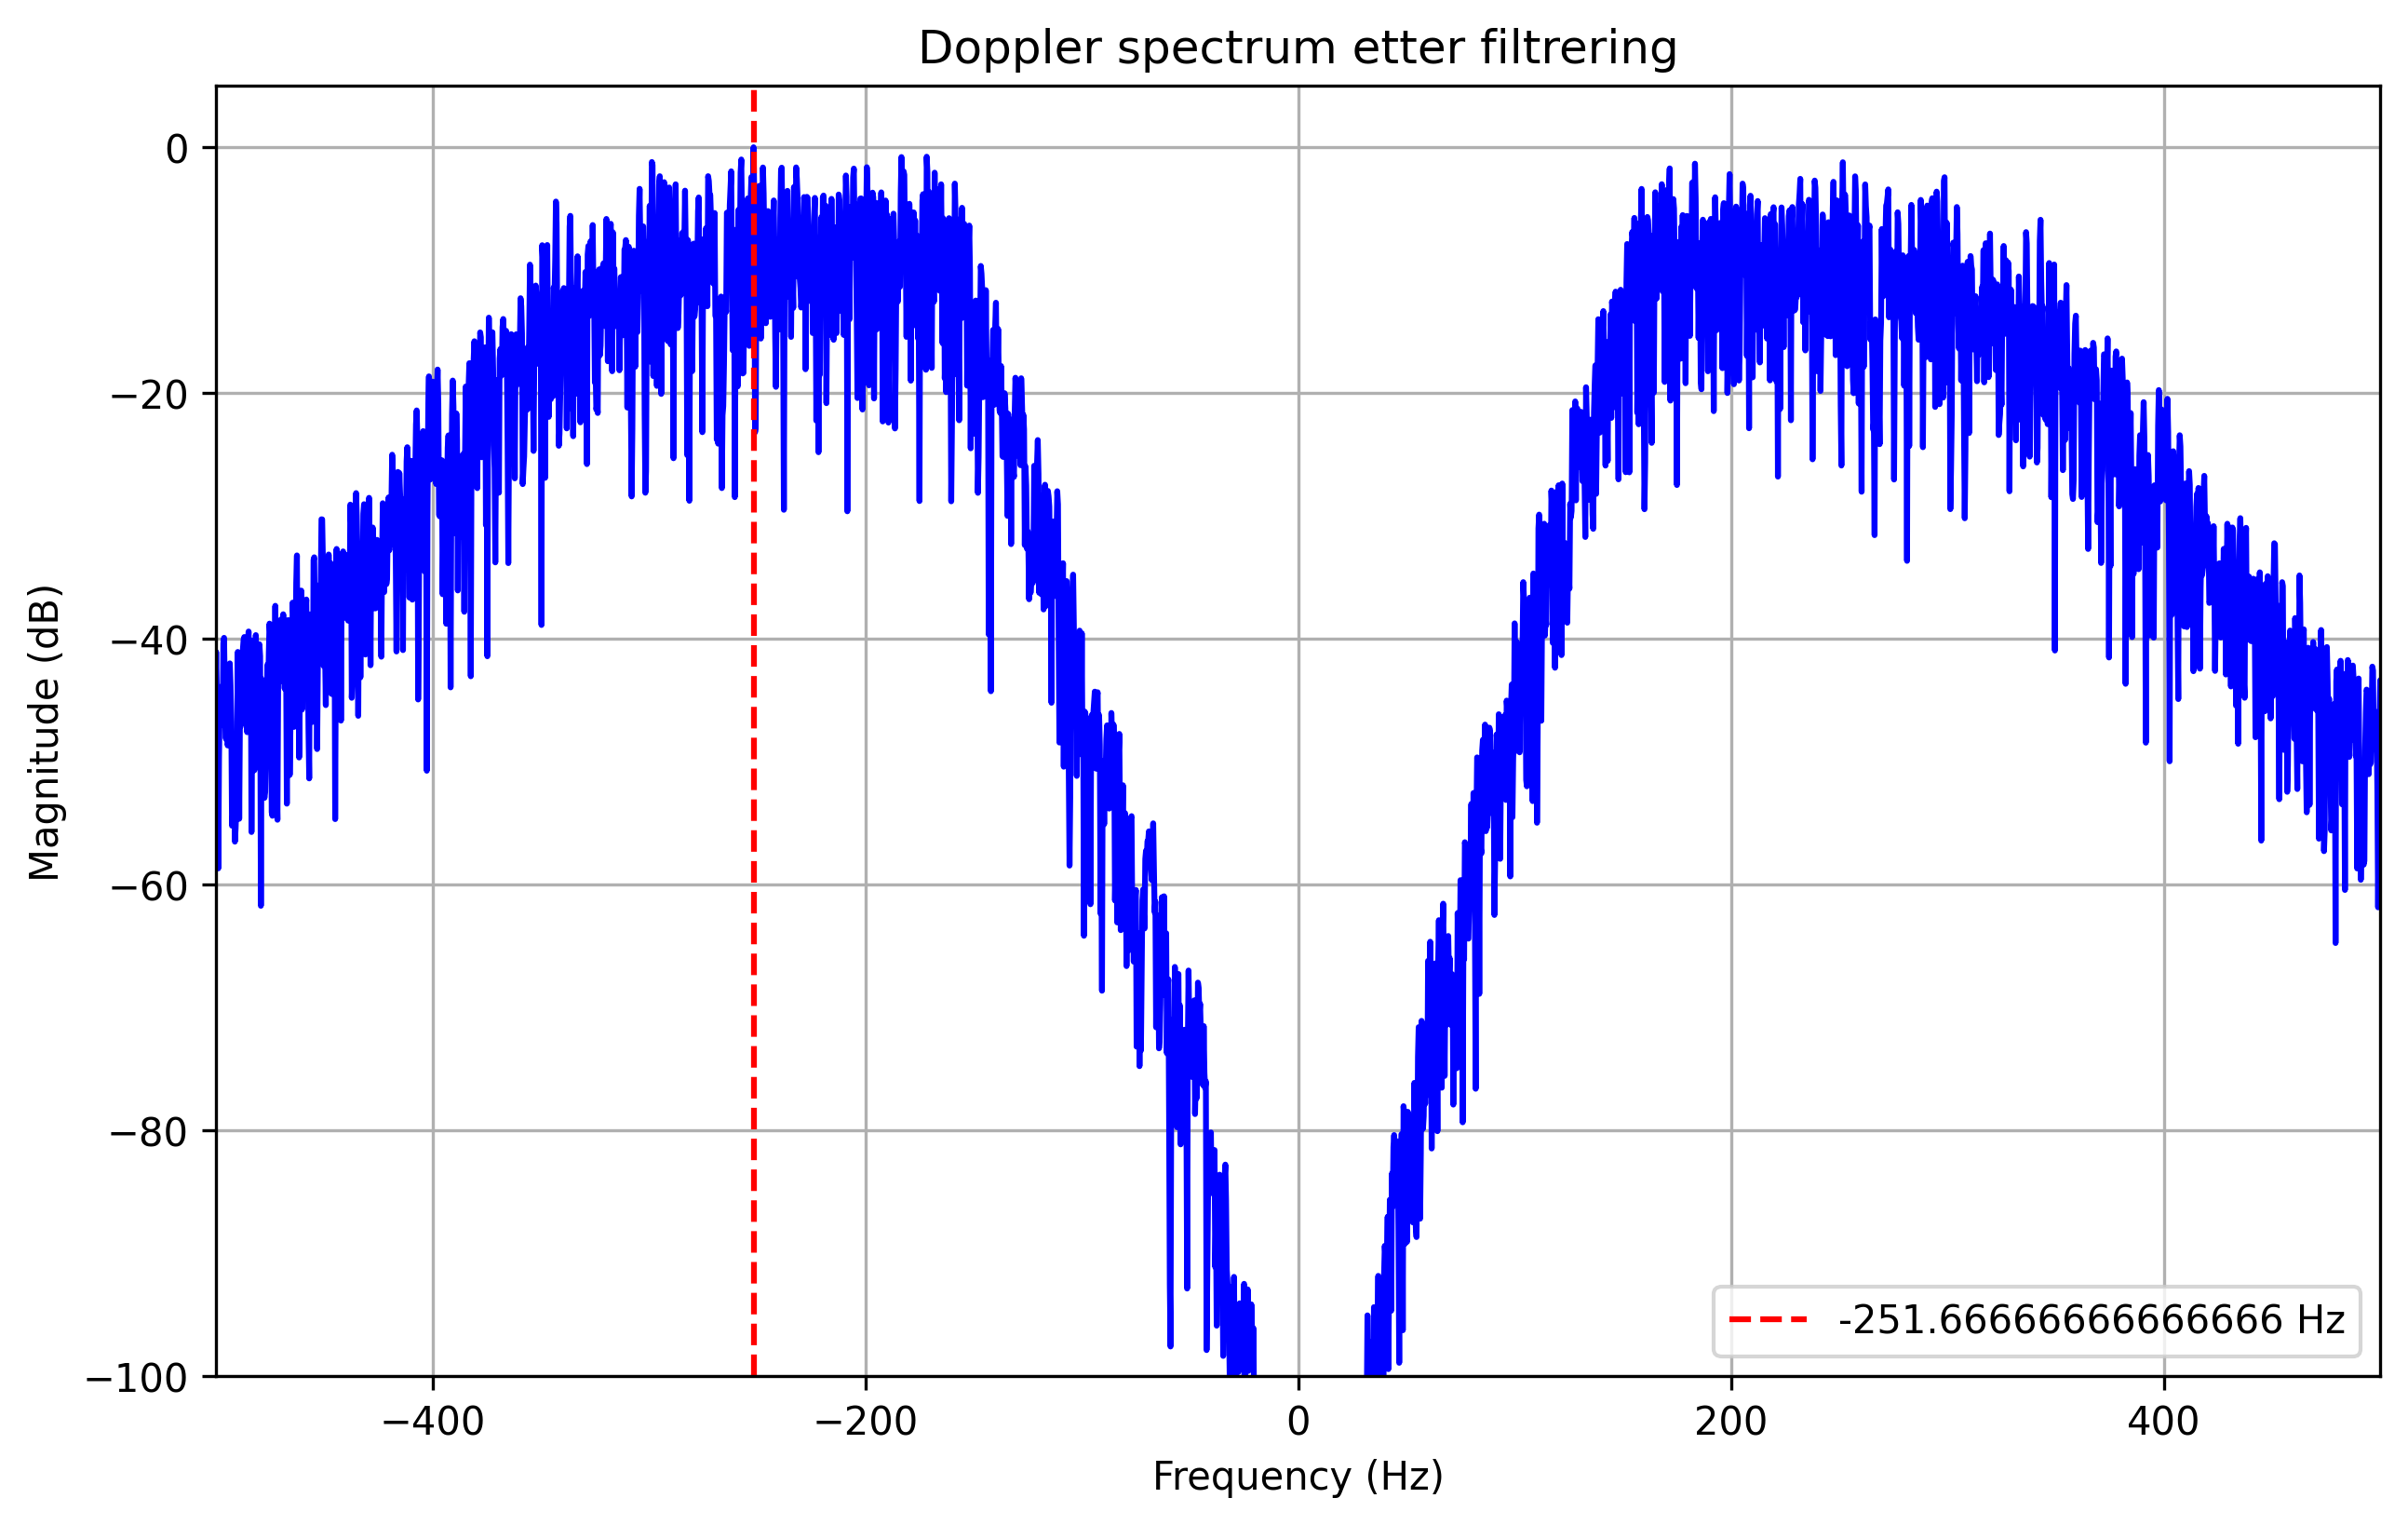

Doppler frequency: -251.66666666666666 Hz
Velocity: -1.5729166666666667 m/s


In [180]:

# -------------------------
# 1. Filtreringsdel
# -------------------------

display(HTML('<h1>Filtrerings parametere </h1>'))
if True:  # Sett til True for Hanning
    window = np.hanning(N)
    window_type = "Hanning"
elif False:  # Sett til True for Hamming
    window = np.hamming(N)
    window_type = "Hamming"
elif False:  # Sett til True for Kaiser
    beta = 8
    window = np.kaiser(N, beta=beta)
    window_type = f"Kaiser (beta={beta})"

c = 3e8
f_radar = 24e9
lam = c / f_radar

v_min = 1
v_max = 2.3

f_min = 2*v_min/lam
f_max = 2*v_max/lam

order = 3

b, a = butter(order, [f_min/(fs/2) , f_max/(fs/2)] , btype='band')  


print(f"Vindu type: {window_type}")

print(f"Minimum hastighet (v_min): {v_min} m/s")
print(f"Maksimum hastighet (v_max): {v_max} m/s")

print(f"Minimum frekvens (f_min): {f_min:.2f} Hz")
print(f"Maksimum frekvens (f_max): {f_max:.2f} Hz")
print(f"Filterorden: {order}")




# Filtrer og vindu
#filtered_IFQ =  IFQ * window
filtered_IFQ = filtfilt(b, a, IFQ * window)
#filtered_IFI = IFI * window
filtered_IFI = filtfilt(b, a, IFI * window)
filtered_s = filtered_IFI + 1j * filtered_IFQ

# -------------------------
# 1.2 Skalering
# -------------------------

display(HTML('<h1>Skalering parametere etter filtrering</h1>'))

amp_I = np.std(filtered_IFI)
amp_Q = np.std(filtered_IFQ)

print("Amplitude IFI:", amp_I)
print("Amplitude IFQ:", amp_Q)

scale = amp_I / amp_Q

filtered_IFQ = filtered_IFQ * scale
amp_Q = np.std(filtered_IFQ)


print("Scale factor:", scale)
print("New amplitude IFQ:", amp_Q)


# -------------------------
# 2. Plotte filtrert og skalert data
# -------------------------

tid = np.arange(len(IFI)) / fs  # Generer tid i sekunder

display(HTML('<h1>Tidsdomene av filtrert signal</h1>'))
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(tid, filtered_IFI, label="IFI", color="blue")
plt.plot(tid, filtered_IFQ, label="IFQ", color="orange")
plt.title("IFI og IFQ etter filtrering")
plt.xlabel("Tid (sekunder)")
plt.ylabel("Verdi")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# -------------------------
# 3. FFT
# -------------------------

S = np.fft.fft(filtered_s)
S = np.fft.fftshift(S)

freq = np.fft.fftshift(
    np.fft.fftfreq(N, sample_period)
)

# -------------------------
# 4. Finn Doppler peak
# -------------------------

idx = np.argmax(np.abs(S))
f_peak = freq[idx]

# -------------------------
# 5. Spektrum i dB
# -------------------------

S_db = 20 * np.log10(np.abs(S) + 1e-12)

display(HTML('<h1>FFT av filtrert signal</h1>'))
plt.figure(figsize=(10,6),dpi=300)
plt.plot(freq, S_db-np.max(S_db), color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Doppler spectrum etter filtrering")
plt.axvline(f_peak, color="red", linestyle="--", label=f"{f_peak} Hz")
plt.legend()
plt.xlim(-500, 500)
plt.ylim(-100, 5)
plt.grid()
plt.show()


# -------------------------
# 6. Regn hastighet
# -------------------------

c = 3e8
f_radar = 24e9

lam = c / f_radar

v = f_peak * lam / 2

display(HTML('<h1>Utregnet fart for filtrert signal</h1>'))
print("Doppler frequency:", f_peak, "Hz")
print("Velocity:", v, "m/s")



# **SNR**

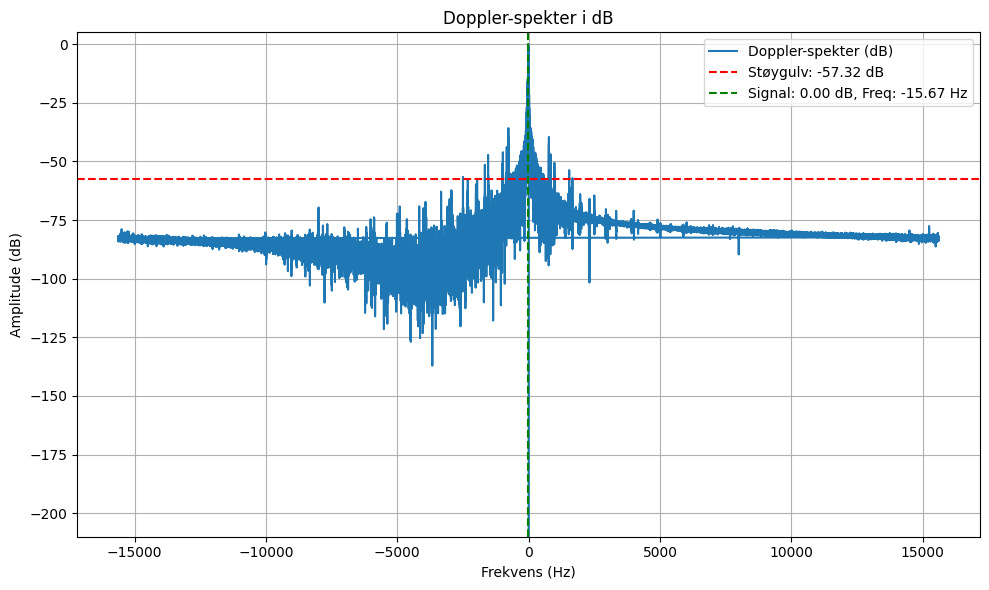

SNR: 57.32 dB
Støygulv: -57.32 dB
Signalstyrke: 0.00 dB



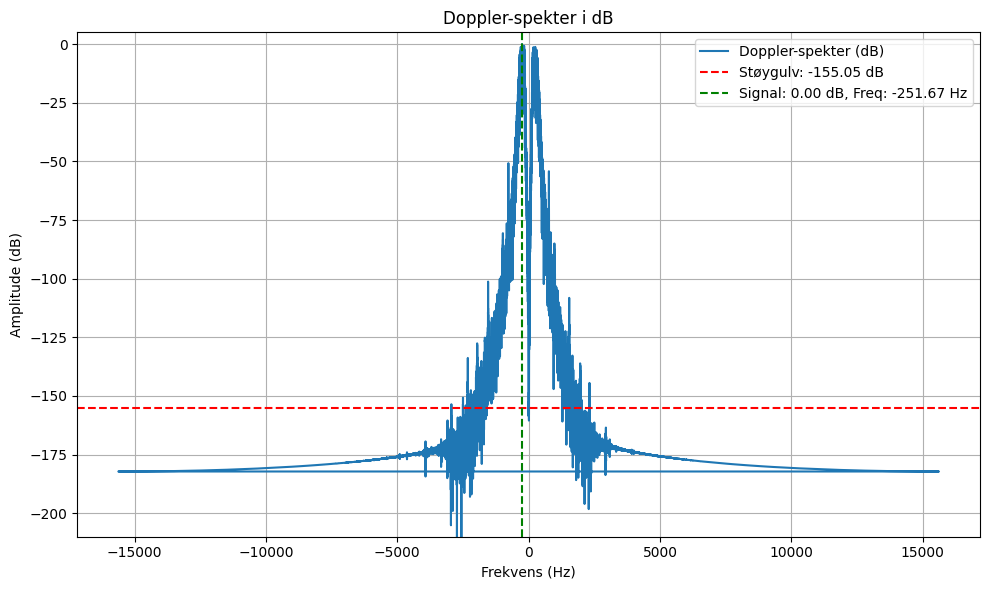

SNR etter filtrering: 155.05 dB
Støygulv etter filtrering: -155.05 dB
Signalstyrke etter filtrering: 0.00 dB


In [181]:
import numpy as np
import matplotlib.pyplot as plt
# === Importer rådata ====

IFI = data[:, 0]
IFQ = data[:, 1]

IFI = IFI - np.mean(IFI)
IFQ = IFQ - np.mean(IFQ)

s = IFI + 1j * IFQ

# === Analyser Doppler-spekter og SNR ====

def analyser_doppler_spekter(filtered_IFQ, fs):
    """
    Analyserer Doppler-spekteret til et signal og beregner SNR.

    Parametere:
        filtered_IFQ (array): Signaldata.
        fs (float): Samplingsfrekvens.

    Returnerer:
        dict: Inneholder 'frequencies', 'doppler_spectrum_db_normalized', 'noise_floor', 'signal_peak', og 'snr'.
    """
    # Beregn Doppler-spekteret
    doppler_spectrum = np.fft.fft(filtered_IFQ)
    frequencies = np.fft.fftfreq(len(doppler_spectrum), d=1/fs)

    # Beregn spekterets amplitude og konverter til dB
    epsilon = 1e-11  # Liten verdi for å unngå log(0)
    spectrum_magnitude = np.abs(doppler_spectrum) + epsilon
    doppler_spectrum_db = 20 * np.log10(spectrum_magnitude)

    # Normaliser spekteret
    signal_peak = np.max(doppler_spectrum_db)
    doppler_spectrum_db_normalized = doppler_spectrum_db - signal_peak

    # Identifiser støygulv og beregn SNR
    noise_floor = np.mean(doppler_spectrum_db_normalized[:10])  # Gjennomsnitt av de første frekvensene som støy
    signal_peak = np.max(doppler_spectrum_db_normalized)  # Maksimal signalstyrke
    snr = signal_peak - noise_floor  # Beregn SNR

    # Plott Doppler-spekteret
    plt.figure(figsize=(10, 6))
    plt.plot(frequencies, doppler_spectrum_db_normalized, label="Doppler-spekter (dB)")
    plt.axhline(noise_floor, color='red', linestyle='--', label=f"Støygulv: {noise_floor:.2f} dB")
    plt.axvline(frequencies[np.argmax(doppler_spectrum_db_normalized)], color='green', linestyle='--', label=f"Signal: {signal_peak:.2f} dB, Freq: {frequencies[np.argmax(doppler_spectrum_db_normalized)]:.2f} Hz")
    plt.title("Doppler-spekter i dB")
    plt.xlabel("Frekvens (Hz)")
    plt.ylabel("Amplitude (dB)")
    plt.ylim(-210, 5)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Returner resultater som en ordbok
    return {
        "frequencies": frequencies,
        "doppler_spectrum_db_normalized": doppler_spectrum_db_normalized,
        "noise_floor": noise_floor,
        "signal_peak": signal_peak,
        "snr": snr
    }

display(HTML('<h1>Ulfiltrert signal</h1>'))
resultater = analyser_doppler_spekter(s, fs)
print(f"SNR: {resultater['snr']:.2f} dB")
print(f"Støygulv: {resultater['noise_floor']:.2f} dB")
print(f"Signalstyrke: {resultater['signal_peak']:.2f} dB\n")

display(HTML('<h1>Filtrert signal</h1>'))
resultater_filtert = analyser_doppler_spekter(filtered_s, fs)
print(f"SNR etter filtrering: {resultater_filtert['snr']:.2f} dB")
print(f"Støygulv etter filtrering: {resultater_filtert['noise_floor']:.2f} dB")
print(f"Signalstyrke etter filtrering: {resultater_filtert['signal_peak']:.2f} dB")


# **OPPLØSNING**

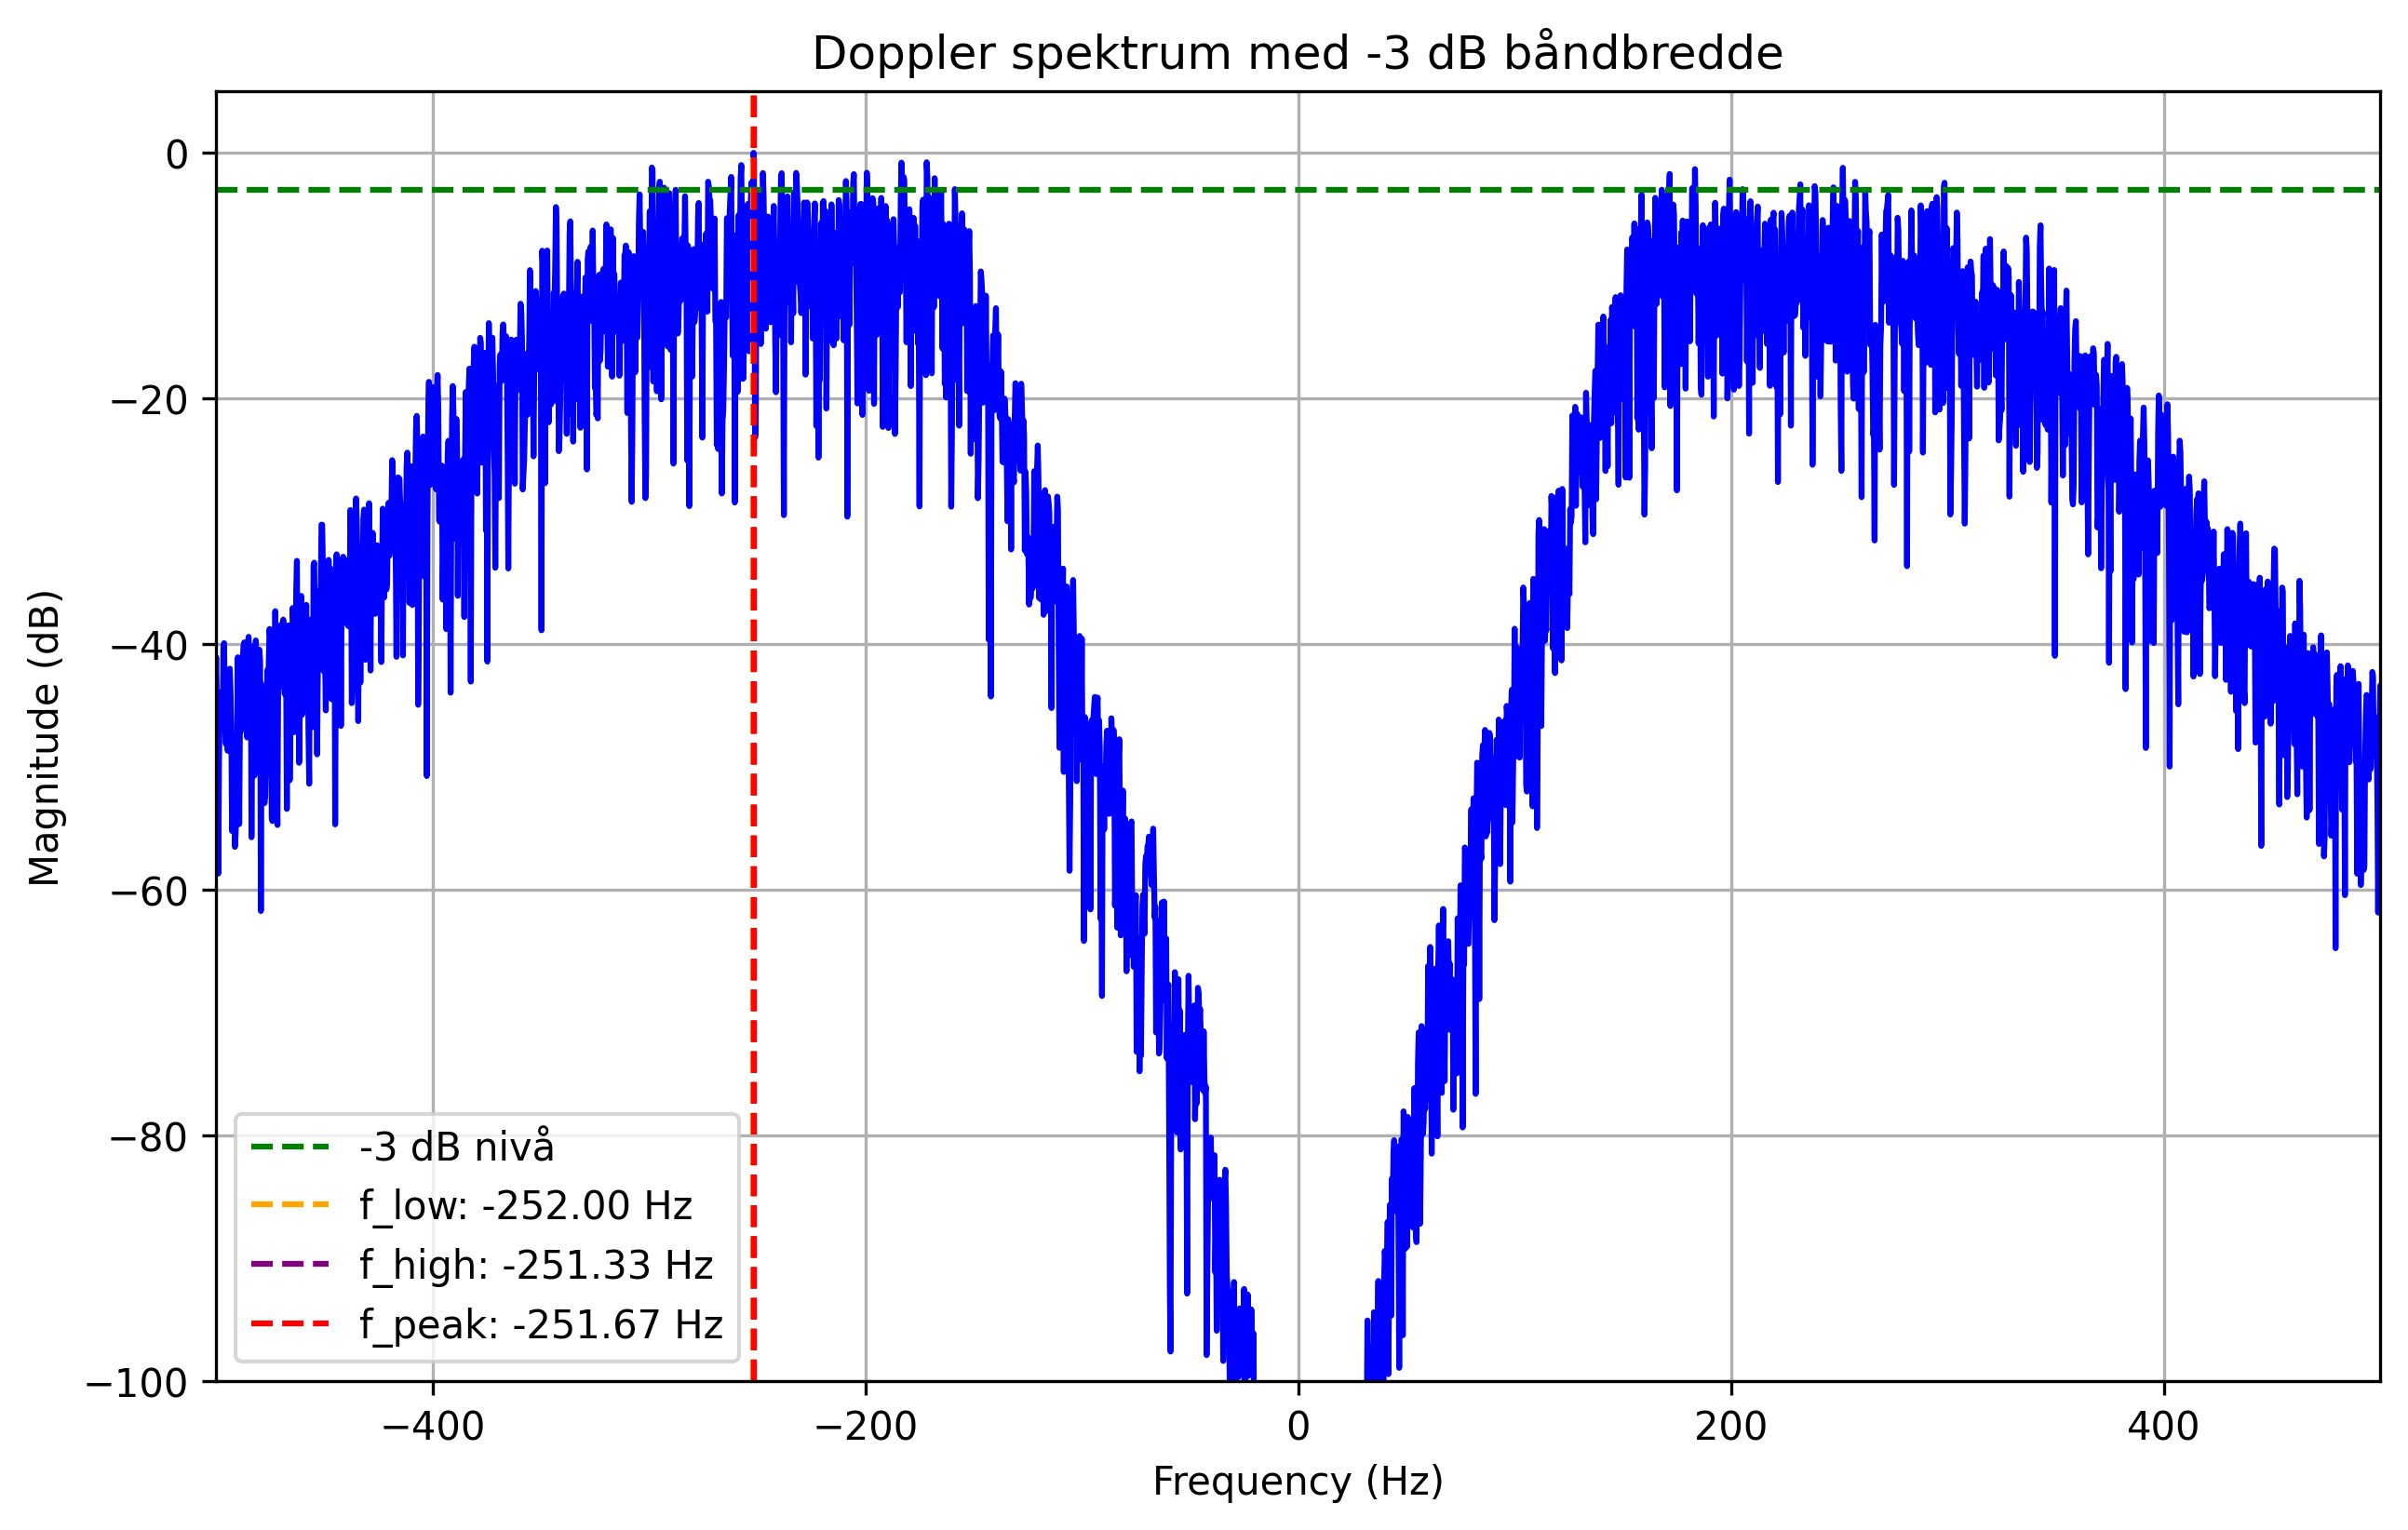

Båndbredde: 0.67 Hz


In [182]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def calculate_bandwidth_from_fft(S, freq):
    """
    Beregn båndbredden på -3 dB rundt peak fra et allerede beregnet FFT-signal.

    Parametere:
    - S: FFT-signalet (komplekse verdier)
    - freq: Frekvensaksen som tilsvarer FFT-signalet

    Returnerer:
    - bandwidth: Båndbredden på -3 dB rundt peak
    - f_low: Laveste frekvens over -3 dB
    - f_high: Høyeste frekvens over -3 dB
    """
    # -------------------------
    # 1. Beregn spektrum i dB
    # -------------------------
    S_db = 20 * np.log10(np.abs(S) + 1e-12)
    idx_peak = np.argmax(S_db)
    f_peak = freq[idx_peak]

    # -------------------------
    # 2. Finn -3 dB nivå
    # -------------------------
    peak_value = S_db[idx_peak]
    threshold = peak_value - 3  # -3 dB nivå


    # Finn -3 dB punktene rett ved peak
    # Søker til venstre for peak
    for i in range(idx_peak, 0, -1):
        if S_db[i] < threshold:
            f_low = freq[i]
            break

    # Søker til høyre for peak
    for i in range(idx_peak, len(S_db)):
        if S_db[i] < threshold:
            f_high = freq[i]
            break
    # Beregn båndbredden
    bandwidth = f_high - f_low

    # -------------------------
    # 3. Plot spektrum med -3 dB nivå
    # -------------------------
    display(HTML('<h1>FFT av filtrert signal</h1>'))
    plt.figure(figsize=(10, 6), dpi=300)
    plt.plot(freq, S_db - np.max(S_db), color="blue")
    plt.axhline(-3, color="green", linestyle="--", label="-3 dB nivå")
    plt.axvline(f_low, color="orange", linestyle="--", label=f"f_low: {f_low:.2f} Hz")
    plt.axvline(f_high, color="purple", linestyle="--", label=f"f_high: {f_high:.2f} Hz")
    plt.axvline(f_peak, color="red", linestyle="--", label=f"f_peak: {f_peak:.2f} Hz")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title("Doppler spektrum med -3 dB båndbredde")
    plt.legend()
    plt.xlim(-500, 500)
    plt.ylim(-100, 5)
    plt.grid()
    plt.show()

    return bandwidth, f_low, f_high

bandwidth, f_low, f_high = calculate_bandwidth_from_fft(S, freq)
print(f"Båndbredde: {bandwidth:.2f} Hz")



# **Varians og standardavik av målt data vs faktisk**

### Fart funksjon *(Bare en funksjons variant av filtreringsdelen)*

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def fart(filepath=None):
    # -------------------------
    # 1. Last inn og behandle data
    # -------------------------
    if filepath is None :
        raise ValueError("Filepath må spesifiseres.")
    
    # Bruk raspi_import for å hente sample_period og data
    sample_period, data = raspi_import(filepath)
    
    fs = 1 / sample_period  # Samplingfrekvens
    N = len(data)  # Antall samples

    # Ekstraher IFI og IFQ
    IFI = data[:, 0]
    IFQ = data[:, 1]

    # Fjern gjennomsnittet
    IFI = IFI - np.mean(IFI)
    IFQ = IFQ - np.mean(IFQ)
    
    c = 3e8
    f_radar = 24e9
    lam = c / f_radar
    v_min = 0.05 
    v_max = 2 
    f_min = 2*v_min/lam
    f_max = 2*v_max/lam
    order = 3
    b, a = butter(order, [f_min/(fs/2) , f_max/(fs/2)] , btype='band')  


    # Filtrer og vindu
    #filtered_IFQ =  IFQ * window
    filtered_IFQ = filtfilt(b, a, IFQ * window)
    #filtered_IFI = IFI * window
    filtered_IFI = filtfilt(b, a, IFI * window)
    filtered_s = filtered_IFI + 1j * filtered_IFQ
    # Kombiner IFI og IFQ til et komplekst signal

    # -------------------------
    # 2. Beregn FFT og frekvens
    # -------------------------
    S = np.fft.fft(filtered_s)
    S = np.fft.fftshift(S)

    freq = np.fft.fftshift(
        np.fft.fftfreq(N, sample_period)
    )

    # -------------------------
    # 3. Finn Doppler peak
    # -------------------------
    idx = np.argmax(np.abs(S))
    f_peak = freq[idx]

    # -------------------------
    # 4. Spektrum i dB
    # -------------------------
    S_db = 20 * np.log10(np.abs(S) + 1e-12)

    # -------------------------
    # 5. Regn hastighet
    # -------------------------
    c = 3e8  # Lysets hastighet (m/s)
    f_radar = 24e9  # Radarens frekvens (Hz)
    lam = c / f_radar  # Bølgelengde

    v = f_peak * lam / 2  # Hastighet (m/s)

    return v

print(f"{fart("Målinger/Radar_vekk1.bin"):.3f} m/s")



0.127 m/s


## Varians

In [184]:
import numpy as np

## INFO: 
# Mot: m1 = 1.316, m2 = 1,329, m3 = 1.294, m4 = 1.055 [m/s]
# Høy hastighet: mh1 = 2.06, mh2 = 2.04, mh3 = 2.08, m4 = 2.01 [m/s]
# Fra: mf = 1.11, mf2 = 1.08, mf3 = 1.04, mf4 = 1.0 [m/s]
mot = np.array([-1.316, -1.329, -1.294, -1.055])  # [m/s]
mot_mean = np.mean(mot)
høy_hastighet = np.array([-2.06, -2.04, -2.08, -2.01])  # [m/s]
mot_h_mean = np.mean(høy_hastighet)
fra = np.array([1.11, 1.08, 1.04, 1.0])  # [m/s]
fra_mean = np.mean(fra)


# Eksempeldata: Hastighetsmålinger (i m/s)
Fart_lav_fremover = [-1.45,-1.401,-1.451, -1.172]
Fart_høy_fremover = [-2.16,-2.03,-2.1,-2.004]
Fart_bakover = [1.35,1.435,1.265,1.248]
# Beregn gjennomsnitt


mean_speed_fremover = np.mean(Fart_lav_fremover)
variance_fremover = np.var(Fart_lav_fremover)
std_deviation_fremover = np.sqrt(variance_fremover)

mean_speed_fremover2 = np.mean(Fart_høy_fremover)
variance_fremover2 = np.var(Fart_høy_fremover)
std_deviation_fremover2 = np.sqrt(variance_fremover2)

mean_speed_bakover = np.mean(Fart_bakover)
variance_bakover = np.var(Fart_bakover)
std_deviation_bakover = np.sqrt(variance_bakover)

# Alternativt kan standardavvik beregnes direkte med np.std()
#std_deviation_direct = np.std(speed_measurements)

# Skriv ut resultatene
display(HTML('<h1>Beregning av varians/standardavvik for hastighetsmålingene</h1>'))

display(HTML('<h2>Fart lav fremover </h2>'))
print(f"Faktisk gjennomsnitlig hastighet: {mot_mean:.3f} m/s")
print(f"Gjennsnitt: {mean_speed_fremover:.2f} m/s")
print(f"Varians: {variance_fremover:.4f} (m/s)^2")
print(f"Standardavvik: {std_deviation_fremover:.4f} m/s")

display(HTML('<h2>Fart høy fremover </h2>'))
print(f"Faktisk gjennomsnitlig hastighet: {mot_h_mean:.3f} m/s")
print(f"Gjennsnitt: {mean_speed_fremover2:.2f} m/s")
print(f"Varians: {variance_fremover2:.4f} (m/s)^2")
print(f"Standardavvik: {std_deviation_fremover2:.4f} m/s")

display(HTML('<h2>Fart bakover </h2>'))
print(f"Faktisk gjennomsnitlig hastighet: {fra_mean:.3f} m/s")
print(f"Gjennsnitt: {mean_speed_bakover:.2f} m/s")
print(f"Varians: {variance_bakover:.4f} (m/s)^2")
print(f"Standardavvik: {std_deviation_bakover:.4f} m/s")


Faktisk gjennomsnitlig hastighet: -1.248 m/s
Gjennsnitt: -1.37 m/s
Varians: 0.0133 (m/s)^2
Standardavvik: 0.1152 m/s


Faktisk gjennomsnitlig hastighet: -2.047 m/s
Gjennsnitt: -2.07 m/s
Varians: 0.0037 (m/s)^2
Standardavvik: 0.0610 m/s


Faktisk gjennomsnitlig hastighet: 1.058 m/s
Gjennsnitt: 1.32 m/s
Varians: 0.0056 (m/s)^2
Standardavvik: 0.0746 m/s
